# SP500 — EDA, Time-Series Decomposition, ARIMA + XGBoost Hybrid

> This notebook performs: (1) exploratory data analysis (EDA) on the provided S&P 500 dataset; (2) time-series decomposition of the **Close** column; (3) ARIMA/SARIMA modeling for trend/seasonality; and (4) an **XGBoost** model on ARIMA residuals to capture shocks (non-white-noise structure).

**How to use**:
1. Ensure the file `SP500.csv` is available in the working directory.
2. Run the *Setup & Imports* cell to install/load dependencies.
3. Execute cells top-to-bottom.

*Notes*:
- Decomposition is shown with both classical decomposition (monthly resample) and STL (daily business-frequency).
- ARIMA order selection uses a small grid search via AIC to avoid requiring `pmdarima`. If you have `pmdarima`, you can optionally enable auto-ARIMA.
- The XGBoost section expects `xgboost` to be installed. If unavailable, install it (see pip cell) or switch to the fallback (commented) alternatives.


In [2]:
# %%capture
# If running locally and you need packages, uncomment the lines below:
# %pip install --upgrade pip
# %pip install pandas numpy matplotlib seaborn plotly statsmodels xgboost scikit-learn pmdarima

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    print('xgboost not found — install it via %pip install xgboost to run the hybrid residual model.')

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.4f}'.format


## 1) Load & Inspect Data

In [4]:
# Adjust path as needed
CSV_PATH = 'SP500.csv'

# Read CSV, parse dates
df = pd.read_csv(CSV_PATH)
# Handle possible weird spacing/headers
df.columns = [c.strip() for c in df.columns]

# Expecting columns including Date, Close; handle case-insensitively
date_col = [c for c in df.columns if c.lower()=='date'][0]
close_col = [c for c in df.columns if c.lower()=='close'][0]

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])
df = df.sort_values(date_col).reset_index(drop=True)

# Set Date index and ensure business-day frequency (we'll also keep original index)
ts = df.set_index(date_col)[close_col].asfreq('B')
# Forward-fill missing business days (markets closed) so tools expecting regular freq work
ts = ts.ffill()

print(df.head())
print('Shape:', df.shape)
print('Missing Close values after ffill? ', ts.isna().sum())
ts.name = 'Close'


        Date   Close    High     Low    Open  Volume
0 1927-12-30 17.6600 17.6600 17.6600 17.6600       0
1 1928-01-03 17.7600 17.7600 17.7600 17.7600       0
2 1928-01-04 17.7200 17.7200 17.7200 17.7200       0
3 1928-01-05 17.5500 17.5500 17.5500 17.5500       0
4 1928-01-06 17.6600 17.6600 17.6600 17.6600       0
Shape: (24532, 6)
Missing Close values after ffill?  0


## 2) Exploratory Data Analysis (EDA)

,Date,Close,High,Low,Open,Volume
count,24532,"24,532.0000","24,532.0000","24,532.0000","24,532.0000","24,532.0000"
mean,1976-11-29 17:31:38.907549344,694.0002,697.8786,689.5705,693.8475,"947,004,829.2027"
min,1927-12-30 00:00:00,4.4000,4.4000,4.4000,4.4000,0.0000
25%,1952-07-21 18:00:00,24.8500,24.8500,24.8500,24.8500,"1,580,000.0000"
50%,1977-01-03 12:00:00,103.1950,104.0150,102.3250,103.1900,"21,415,000.0000"
75%,2001-04-10 06:00:00,"1,075.5400","1,084.5950","1,066.6049","1,075.5400","1,114,100,000.0000"
max,2025-08-29 00:00:00,"6,501.8599","6,508.2300","6,466.9600","6,489.2798","11,456,230,000.0000"
std,NaN,"1,165.4443","1,171.5107","1,158.4457","1,165.1974","1,658,918,173.7736"


Duplicate dates: 0
Nulls by column:


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

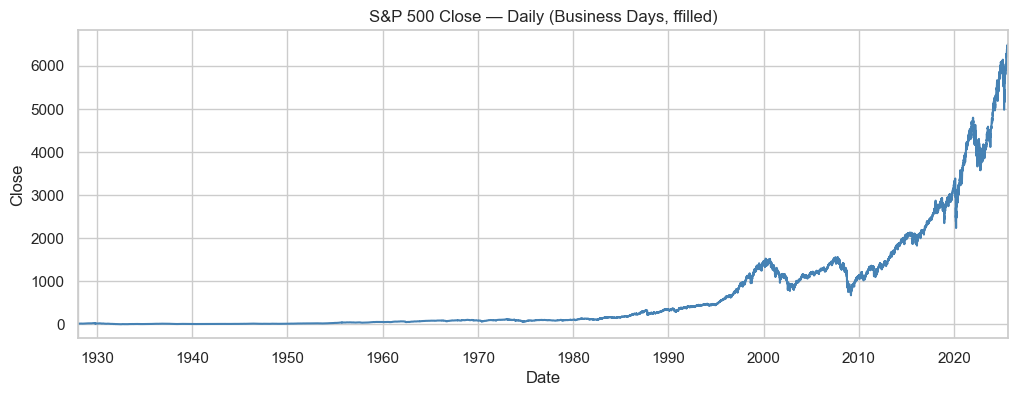

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'Date=%{x}<br>Close=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array(['1927-12-30T00:00:00.000000000', '1928-01-02T00:00:00.000000000',
                          '1928-01-03T00:00:00.000000000', ..., '2025-08-27T00:00:00.000000000',
                          '2025-08-28T00:00:00.000000000', '2025-08-29T00:00:00.000000000'],
                         shape=(25481,), dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('ah0LwPWoMUBqHQvA9agxQG/NBGCPwj' ... '9mUblACkj7H9xluUCdSgaAQjy5QA=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'height': 400,
               'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'S&P 500 Close — Interactive'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Date'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Close'}}}
})

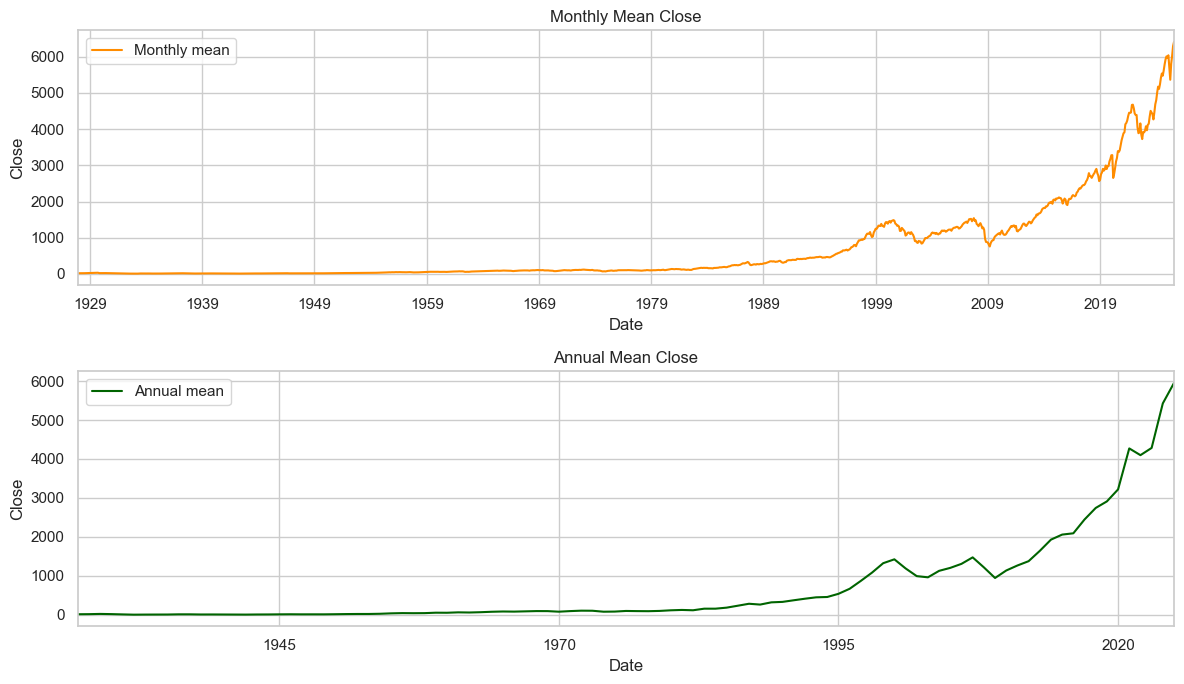

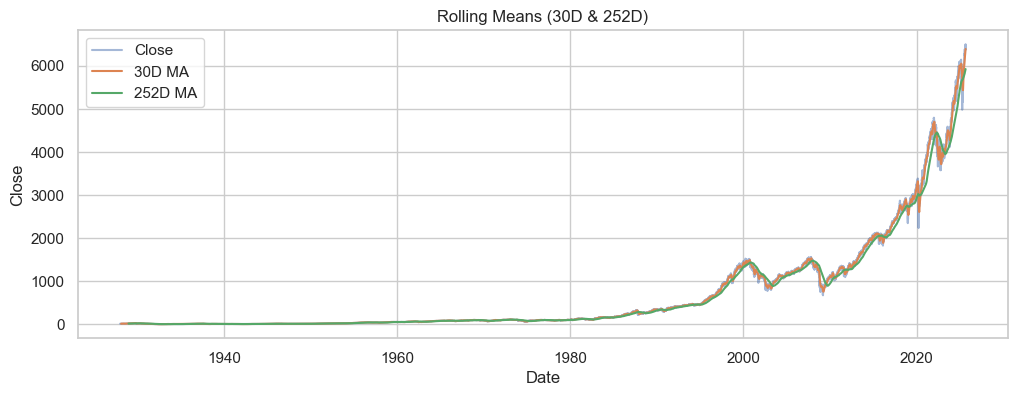

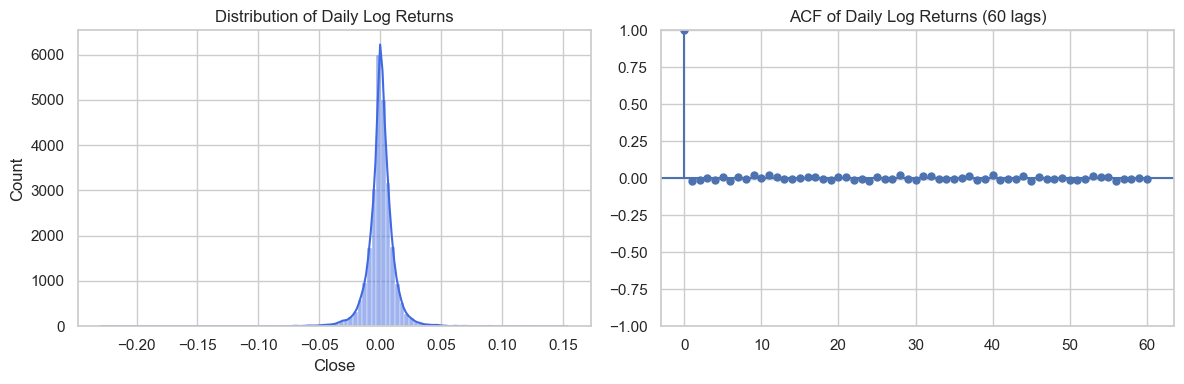

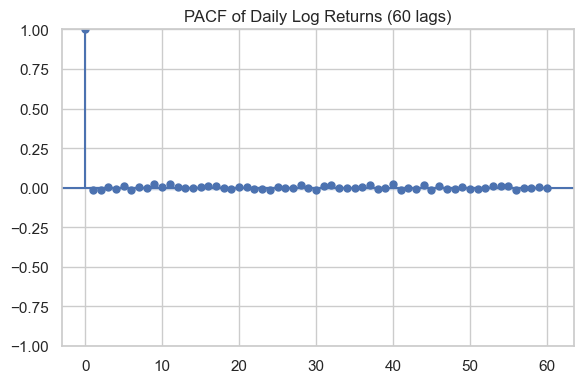

ADF Statistic (log Close): 0.7833522909884197
p-value: 0.9913626344222003


In [7]:
# Summary stats
display(df.describe(include='all'))

# Check duplicates and missing
dup_dates = df.duplicated(subset=[date_col]).sum()
print(f'Duplicate dates: {dup_dates}')
print('Nulls by column:')
display(df.isna().sum())

# Plot Close over time (matplotlib)
fig, ax = plt.subplots(figsize=(12,4))
ts.plot(ax=ax, color='steelblue')
ax.set_title('S&P 500 Close — Daily (Business Days, ffilled)')
ax.set_xlabel('Date'); ax.set_ylabel('Close')
plt.show()

# Interactive zoomable plot
display(px.line(ts.reset_index(), x=ts.index.name, y='Close', title='S&P 500 Close — Interactive').update_layout(height=400))

# Resampled views: Monthly & Yearly
ts_m = ts.resample('M').mean()
ts_y = ts.resample('Y').mean()
fig, axes = plt.subplots(2,1, figsize=(12,7), sharex=False)
ts_m.plot(ax=axes[0], color='darkorange', label='Monthly mean')
axes[0].set_title('Monthly Mean Close')
ts_y.plot(ax=axes[1], color='darkgreen', label='Annual mean')
axes[1].set_title('Annual Mean Close')
for ax in axes: ax.legend(); ax.set_xlabel('Date'); ax.set_ylabel('Close')
plt.tight_layout(); plt.show()

# Rolling statistics
roll_30 = ts.rolling(30).mean()
roll_252 = ts.rolling(252).mean()  # ~ annual trading days
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(ts.index, ts, label='Close', alpha=0.5)
ax.plot(roll_30.index, roll_30, label='30D MA')
ax.plot(roll_252.index, roll_252, label='252D MA')
ax.set_title('Rolling Means (30D & 252D)')
ax.legend(); ax.set_xlabel('Date'); ax.set_ylabel('Close'); plt.show()

# Log returns distribution and ACF/PACF
log_close = np.log(ts)
log_ret = log_close.diff().dropna()
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(log_ret, bins=100, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Daily Log Returns')
plot_acf(log_ret, lags=60, ax=axes[1])
axes[1].set_title('ACF of Daily Log Returns (60 lags)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(6,4))
plot_pacf(log_ret, lags=60, ax=ax, method='ywm')
ax.set_title('PACF of Daily Log Returns (60 lags)')
plt.tight_layout(); plt.show()

# Stationarity check (ADF) on log Close
adf_res = adfuller(log_close.dropna())
print('ADF Statistic (log Close):', adf_res[0])
print('p-value:', adf_res[1])


## 3) Time-Series Decomposition of `Close`
We'll show two approaches:
- **Classical decomposition** on a **monthly** average series (period=12).
- **STL (Seasonal-Trend decomposition using Loess)** on a **daily business-frequency** series (period ≈ 252 trading days).

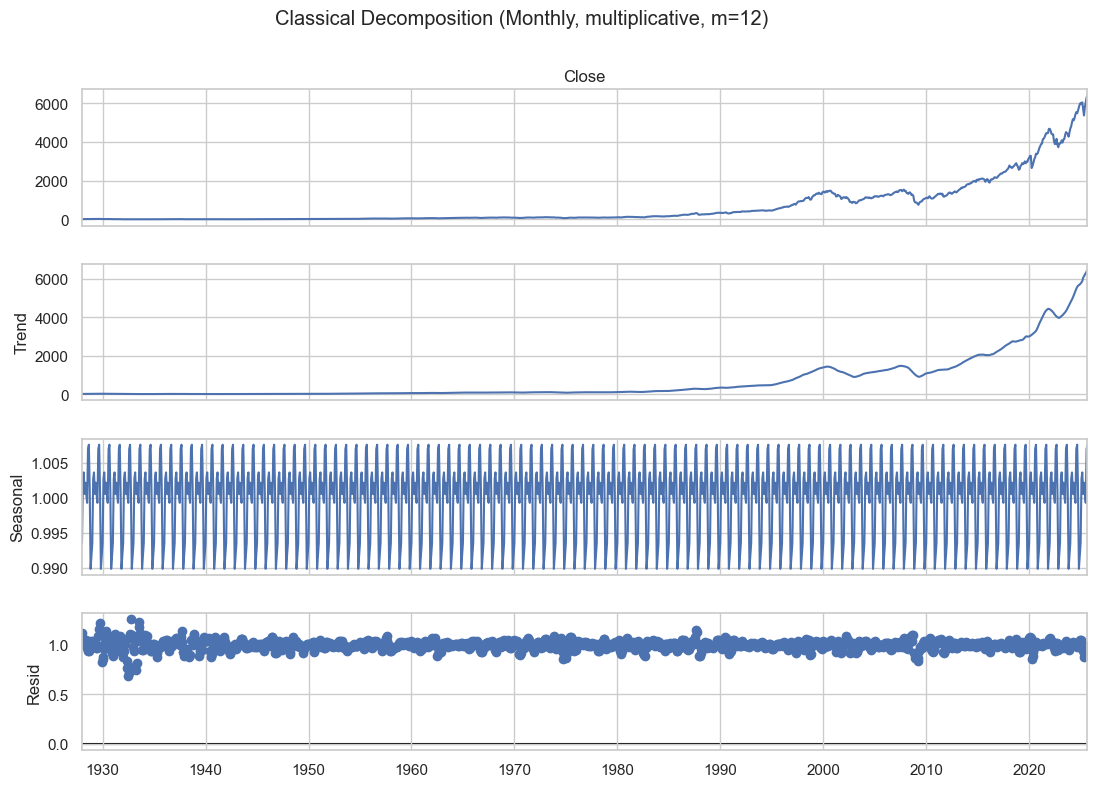

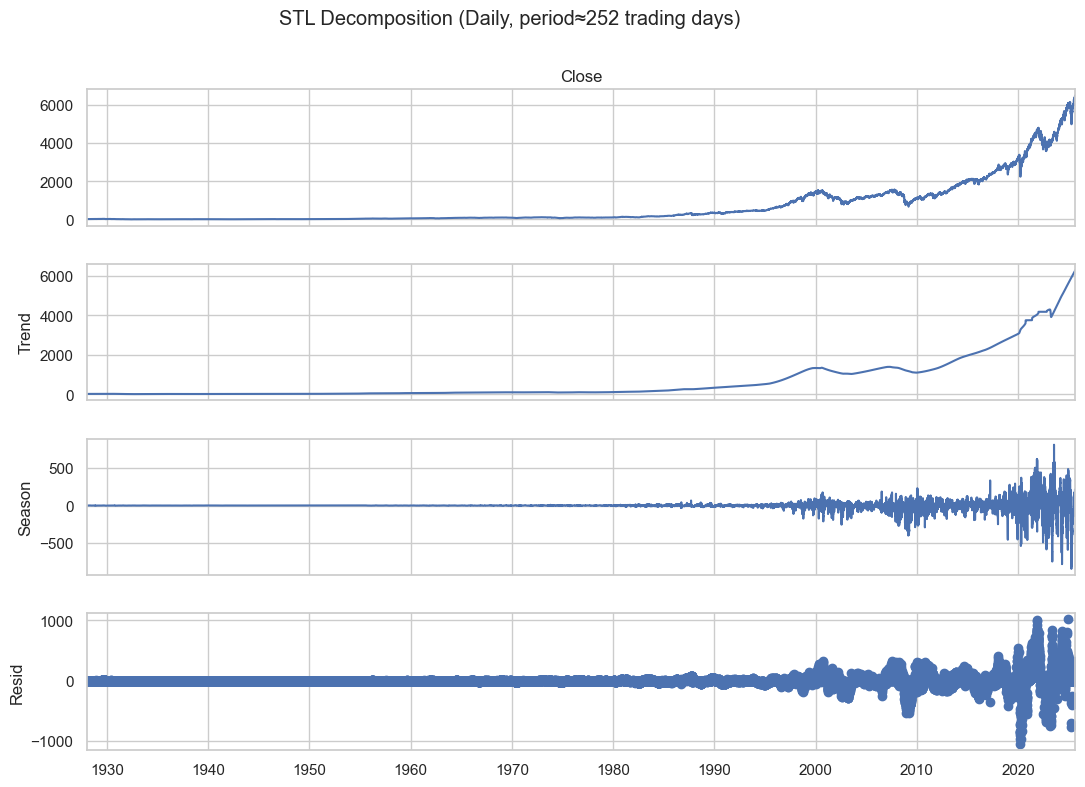

In [8]:
# Monthly classical decomposition (multiplicative often suits trending series)
ts_m = ts.resample('M').mean().dropna()
decomp = seasonal_decompose(ts_m, model='multiplicative', period=12, two_sided=True, extrapolate_trend='freq')
fig = decomp.plot()
fig.set_size_inches(12,8)
fig.suptitle('Classical Decomposition (Monthly, multiplicative, m=12)', y=1.02)
plt.show()

# STL on daily business-frequency, using ~annual trading seasonality
stl = STL(ts.dropna(), period=252, robust=True)
stl_res = stl.fit()
fig = stl_res.plot()
fig.set_size_inches(12,8)
fig.suptitle('STL Decomposition (Daily, period≈252 trading days)', y=1.02)
plt.show()


## 4) ARIMA/SARIMA to Model Trend & Seasonality
We build a seasonal ARIMA on the **monthly mean of log Close**.
- We grid-search a small set of orders by AIC (you can widen if desired).

C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

C:\Users\ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood opti

Best AIC: -3394.310678604964
Best order: (1, 0, 1)
Best seasonal: (0, 0, 0, 12)


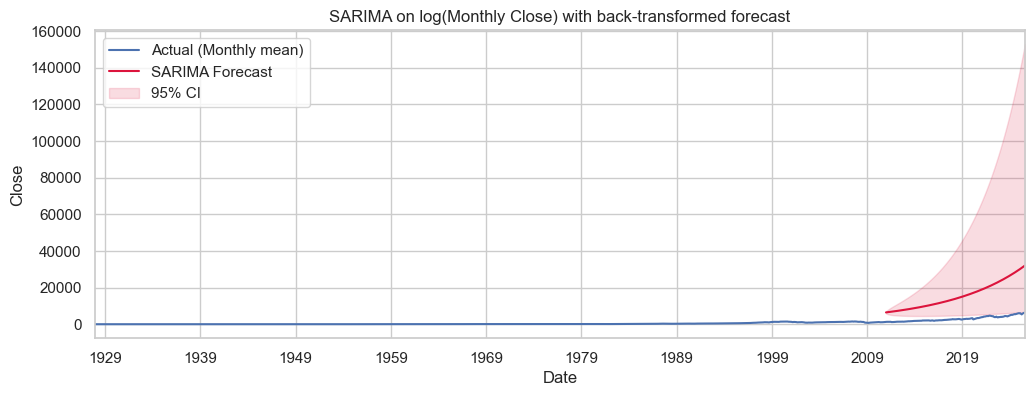

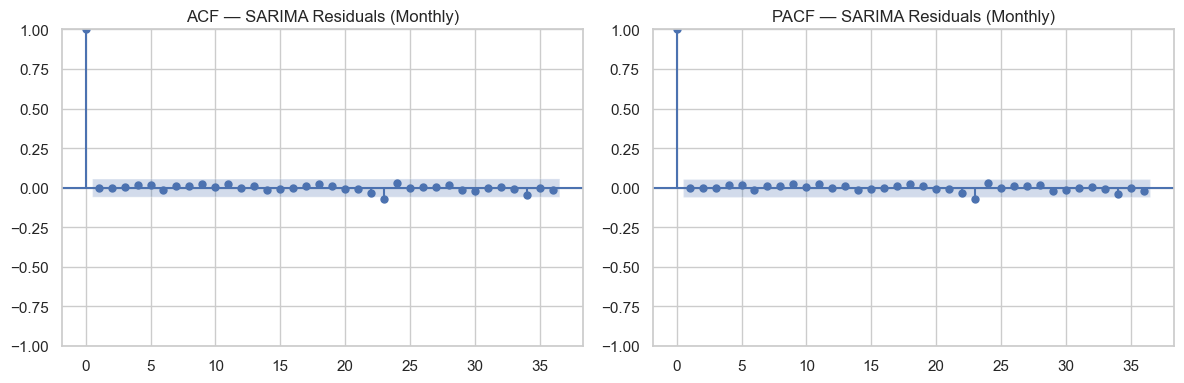

Ljung-Box test p-values:


,lb_stat,lb_pvalue
12,2.2906,0.9988
24,11.6666,0.9834
36,16.0105,0.9984


In [9]:
ts_m = ts.resample('M').mean().dropna()
ts_m_log = np.log(ts_m).dropna()
train_frac = 0.85
n_train = int(len(ts_m_log)*train_frac)
y_train, y_test = ts_m_log.iloc[:n_train], ts_m_log.iloc[n_train:]

p = d = q = [0,1,2]
P = D = Q = [0,1]
m = 12
best_aic = np.inf
best_order = None
best_seasonal = None
best_model = None
for pi in p:
    for di in d:
        for qi in q:
            for Pi in P:
                for Di in D:
                    for Qi in Q:
                        try:
                            model = SARIMAX(y_train, order=(pi,di,qi), seasonal_order=(Pi,Di,Qi,m), enforce_stationarity=False, enforce_invertibility=False)
                            resi = model.fit(disp=False)
                            if resi.aic < best_aic:
                                best_aic = resi.aic
                                best_order = (pi,di,qi)
                                best_seasonal = (Pi,Di,Qi,m)
                                best_model = resi
                        except Exception as e:
                            pass

print('Best AIC:', best_aic)
print('Best order:', best_order)
print('Best seasonal:', best_seasonal)

# Refit on full series and forecast the test horizon
model = SARIMAX(ts_m_log, order=best_order, seasonal_order=best_seasonal, enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
fcast = res.get_forecast(steps=len(y_test))
fcast_mean = fcast.predicted_mean
fcast_ci = fcast.conf_int()

# Back transform to level
fcast_lvl = np.exp(fcast_mean)

fig, ax = plt.subplots(figsize=(12,4))
ts_m.plot(ax=ax, label='Actual (Monthly mean)')
fcast_lvl.index = y_test.index
fcast_lvl.plot(ax=ax, label='SARIMA Forecast', color='crimson')
ax.fill_between(y_test.index, np.exp(fcast_ci.iloc[:,0]), np.exp(fcast_ci.iloc[:,1]), color='crimson', alpha=0.15, label='95% CI')
ax.set_title('SARIMA on log(Monthly Close) with back-transformed forecast')
ax.legend(); ax.set_xlabel('Date'); ax.set_ylabel('Close'); plt.show()

# Residual diagnostics
resid = res.resid.dropna()
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(resid, lags=36, ax=axes[0])
plot_pacf(resid, lags=36, ax=axes[1], method='ywm')
axes[0].set_title('ACF — SARIMA Residuals (Monthly)'); axes[1].set_title('PACF — SARIMA Residuals (Monthly)')
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(resid, lags=[12,24,36], return_df=True)
print('Ljung-Box test p-values:')
display(lb)

sarima_resid = resid


### (Optional) Auto-ARIMA (requires `pmdarima`)
If you have `pmdarima` installed, you can try:
```python
from pmdarima import auto_arima
auto_model = auto_arima(ts_m_log, seasonal=True, m=12, trace=True, stepwise=True)
auto_model.summary()
```

## 5) XGBoost on ARIMA Residuals — Predicting Shocks
We model residuals as a supervised learning task: predict next residual from lagged residuals and simple technical features.
The final **hybrid** forecast = SARIMA forecast **+** XGBoost-predicted residual.

XGBoost residual model — Valid RMSE: 0.020418, MAE: 0.012912


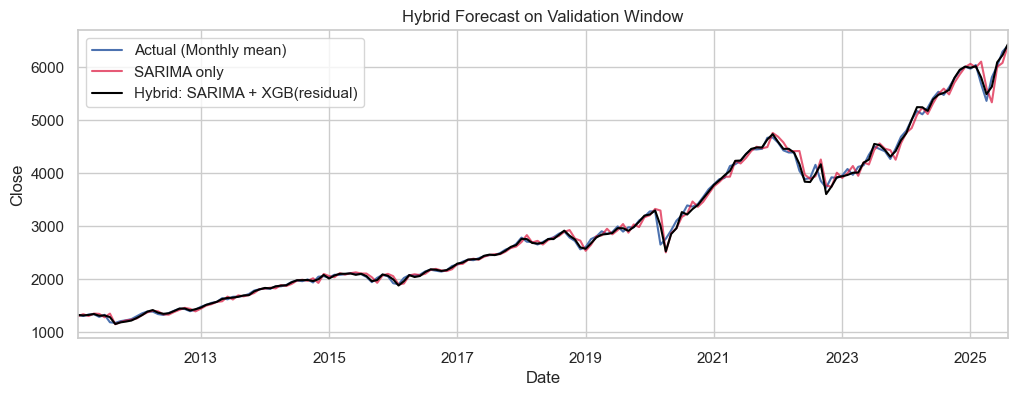

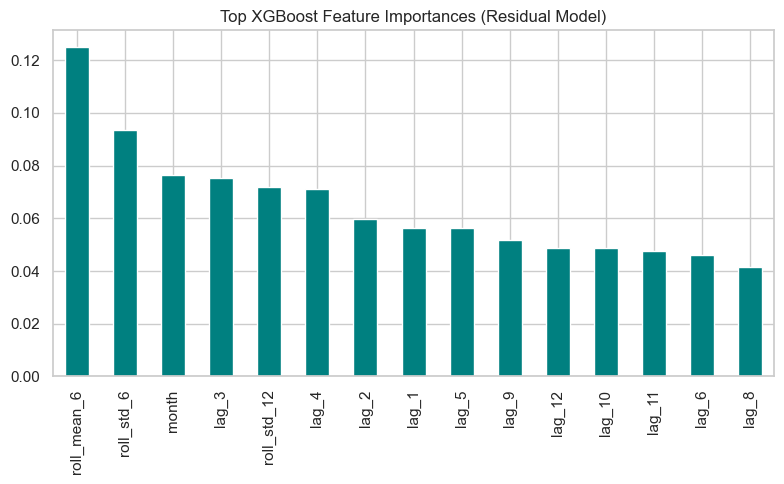

In [10]:
from sklearn.metrics import root_mean_squared_error


if not XGB_AVAILABLE:
    print('xgboost is not installed. Install with %pip install xgboost and re-run this cell.')
else:
    # Build a feature matrix from residuals (monthly)
    R = sarima_resid.dropna().to_frame('resid').copy()
    # Lags
    for L in range(1,13):
        R[f'lag_{L}'] = R['resid'].shift(L)
    # Rolling stats
    R['roll_std_6'] = R['resid'].rolling(6).std()
    R['roll_std_12'] = R['resid'].rolling(12).std()
    R['roll_mean_6'] = R['resid'].rolling(6).mean()
    R['month'] = R.index.month
    R = R.dropna()

    # Train/valid split (time-based)
    split_idx = int(len(R)*0.85)
    train, valid = R.iloc[:split_idx], R.iloc[split_idx:]
    X_tr, y_tr = train.drop(columns=['resid']), train['resid']
    X_va, y_va = valid.drop(columns=['resid']), valid['resid']

    xgb = XGBRegressor(
        n_estimators=800,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    # In-time validation performance
    pred_va = xgb.predict(X_va)
    rmse = root_mean_squared_error(y_va, pred_va)
    mae = mean_absolute_error(y_va, pred_va)
    print(f'XGBoost residual model — Valid RMSE: {rmse:.6f}, MAE: {mae:.6f}')

    # Hybrid forecast for validation window
    sarima_fitted = res.get_prediction(start=valid.index[0], end=valid.index[-1])
    sarima_mean_log = sarima_fitted.predicted_mean
    sarima_mean_lvl = np.exp(sarima_mean_log)

    # Combine on log scale then exponentiate
    hybrid_log = sarima_mean_log.loc[valid.index] + pred_va
    hybrid_lvl = np.exp(hybrid_log)

    fig, ax = plt.subplots(figsize=(12,4))
    ts_m.loc[valid.index].plot(ax=ax, label='Actual (Monthly mean)')
    sarima_mean_lvl.loc[valid.index].plot(ax=ax, label='SARIMA only', color='crimson', alpha=0.7)
    hybrid_lvl.plot(ax=ax, label='Hybrid: SARIMA + XGB(residual)', color='black')
    ax.set_title('Hybrid Forecast on Validation Window')
    ax.legend(); ax.set_xlabel('Date'); ax.set_ylabel('Close'); plt.show()

    # Feature importance
    importances = pd.Series(xgb.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8,5))
    importances.head(15).plot(kind='bar', ax=ax, color='teal')
    ax.set_title('Top XGBoost Feature Importances (Residual Model)'); plt.tight_layout(); plt.show()


Forecasting for dates: 2025-09-02 00:00:00 to 2025-10-13 00:00:00

Comparison of Forecast vs Actual:
               Actual   Forecast       Error  Error %
Date                                                 
2025-09-02 6,415.5400 6,312.4466    103.0935   1.6069
2025-09-03 6,448.2598 6,365.7022     82.5576   1.2803
2025-09-04 6,502.0801 6,419.4587     82.6214   1.2707
2025-09-05 6,481.5000 6,473.7214      7.7786   0.1200
2025-09-08 6,495.1499 6,528.4953    -33.3454  -0.5134
2025-09-09 6,512.6099 6,583.7858    -71.1759  -1.0929
2025-09-10 6,532.0400 6,639.5982   -107.5581  -1.6466
2025-09-11 6,587.4702 6,695.9378   -108.4676  -1.6466
2025-09-12 6,584.2900 6,752.8101   -168.5201  -2.5594
2025-09-15 6,615.2798 6,810.2206   -194.9409  -2.9468
2025-09-16 6,606.7598 6,868.1749   -261.4152  -3.9568
2025-09-17 6,600.3501 6,926.6786   -326.3285  -4.9441
2025-09-18 6,631.9600 6,985.7374   -353.7774  -5.3344
2025-09-19 6,664.3599 7,045.3570   -380.9971  -5.7169
2025-09-22 6,693.7500 7,105.5432   

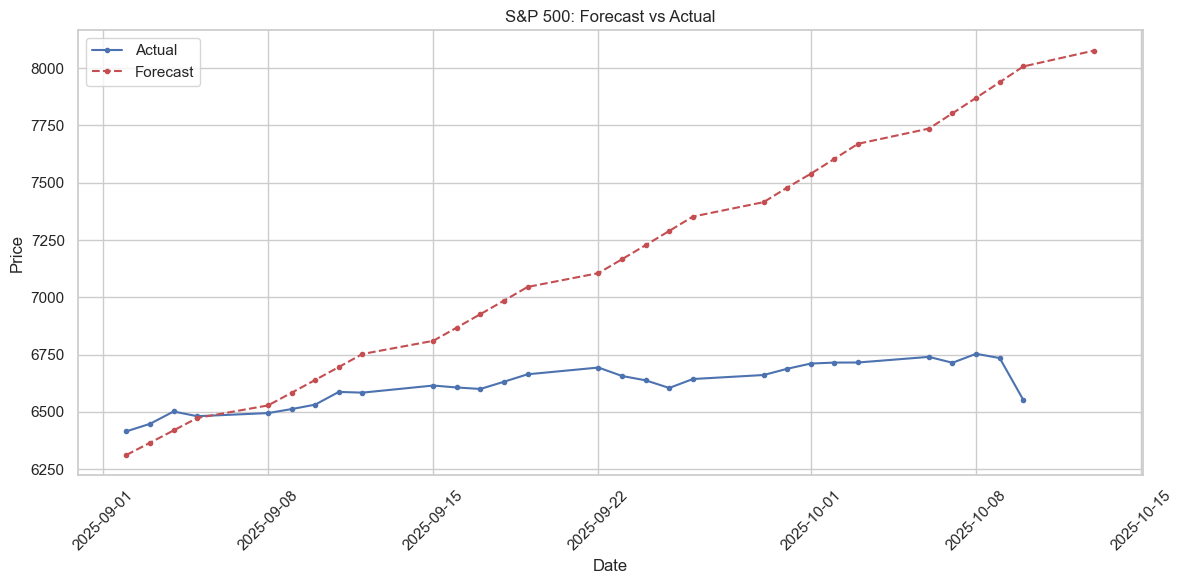

In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get 30-day forecast dates
future_dates = pd.date_range(start=ts_m.index[-1], periods=31, freq='B')[1:]  # Business days
print("Forecasting for dates:", future_dates[0], "to", future_dates[-1])

# Generate forecast
future_sarima = res.get_forecast(steps=len(future_dates))
future_sarima_mean = future_sarima.predicted_mean
future_hybrid_log = future_sarima_mean + xgb.predict(future_features)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': np.exp(future_hybrid_log)
}).set_index('Date')

# Get actual S&P 500 data
actual_df = yf.download('^GSPC', start=future_dates[0], end=future_dates[-1], progress=False)[['Close']]
actual_df.columns = ['Actual']

# Merge forecast and actual data
comparison_df = actual_df.join(forecast_df, how='outer')
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Forecast']
comparison_df['Error %'] = (comparison_df['Error'] / comparison_df['Actual']) * 100

# Print the merged data
print("\nComparison of Forecast vs Actual:")
print(comparison_df)

# Print summary statistics
valid_errors = comparison_df.dropna()
print("\nError Summary:")
print(f"Mean Error: ${valid_errors['Error'].mean():.2f}")
print(f"Mean Absolute Error: ${abs(valid_errors['Error']).mean():.2f}")
print(f"Mean Percentage Error: {valid_errors['Error %'].mean():.2f}%")
print(f"Root Mean Square Error: ${np.sqrt((valid_errors['Error']**2).mean()):.2f}")

# Simple plot
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 'b.-', label='Actual')
plt.plot(comparison_df.index, comparison_df['Forecast'], 'r.--', label='Forecast')
plt.title('S&P 500: Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Annual Forecast Analysis

One-year forecast period: 2025-09-02 00:00:00 to 2026-08-18 00:00:00

Comparison of One-Year Forecast vs Actual:

First few days:
               Actual   Forecast    Error  Error %
Date                                              
2025-09-02 6,415.5400 6,312.4466 103.0935   1.6069
2025-09-03 6,448.2598 6,365.7022  82.5576   1.2803
2025-09-04 6,502.0801 6,419.4587  82.6214   1.2707
2025-09-05 6,481.5000 6,473.7214   7.7786   0.1200
2025-09-08 6,495.1499 6,528.4953 -33.3454  -0.5134

Last few days:
            Actual    Forecast  Error  Error %
Date                                          
2026-08-12     NaN 64,824.1692    NaN      NaN
2026-08-13     NaN 65,517.0244    NaN      NaN
2026-08-14     NaN 66,217.9592    NaN      NaN
2026-08-17     NaN 66,927.0749    NaN      NaN
2026-08-18     NaN 67,644.4743    NaN      NaN

Error Summary (for available actual data):
Number of trading days compared: 43
Mean Error: $-929.33
Mean Absolute Error: $942.17
Mean Percentage Error: -13.82%
Root Me

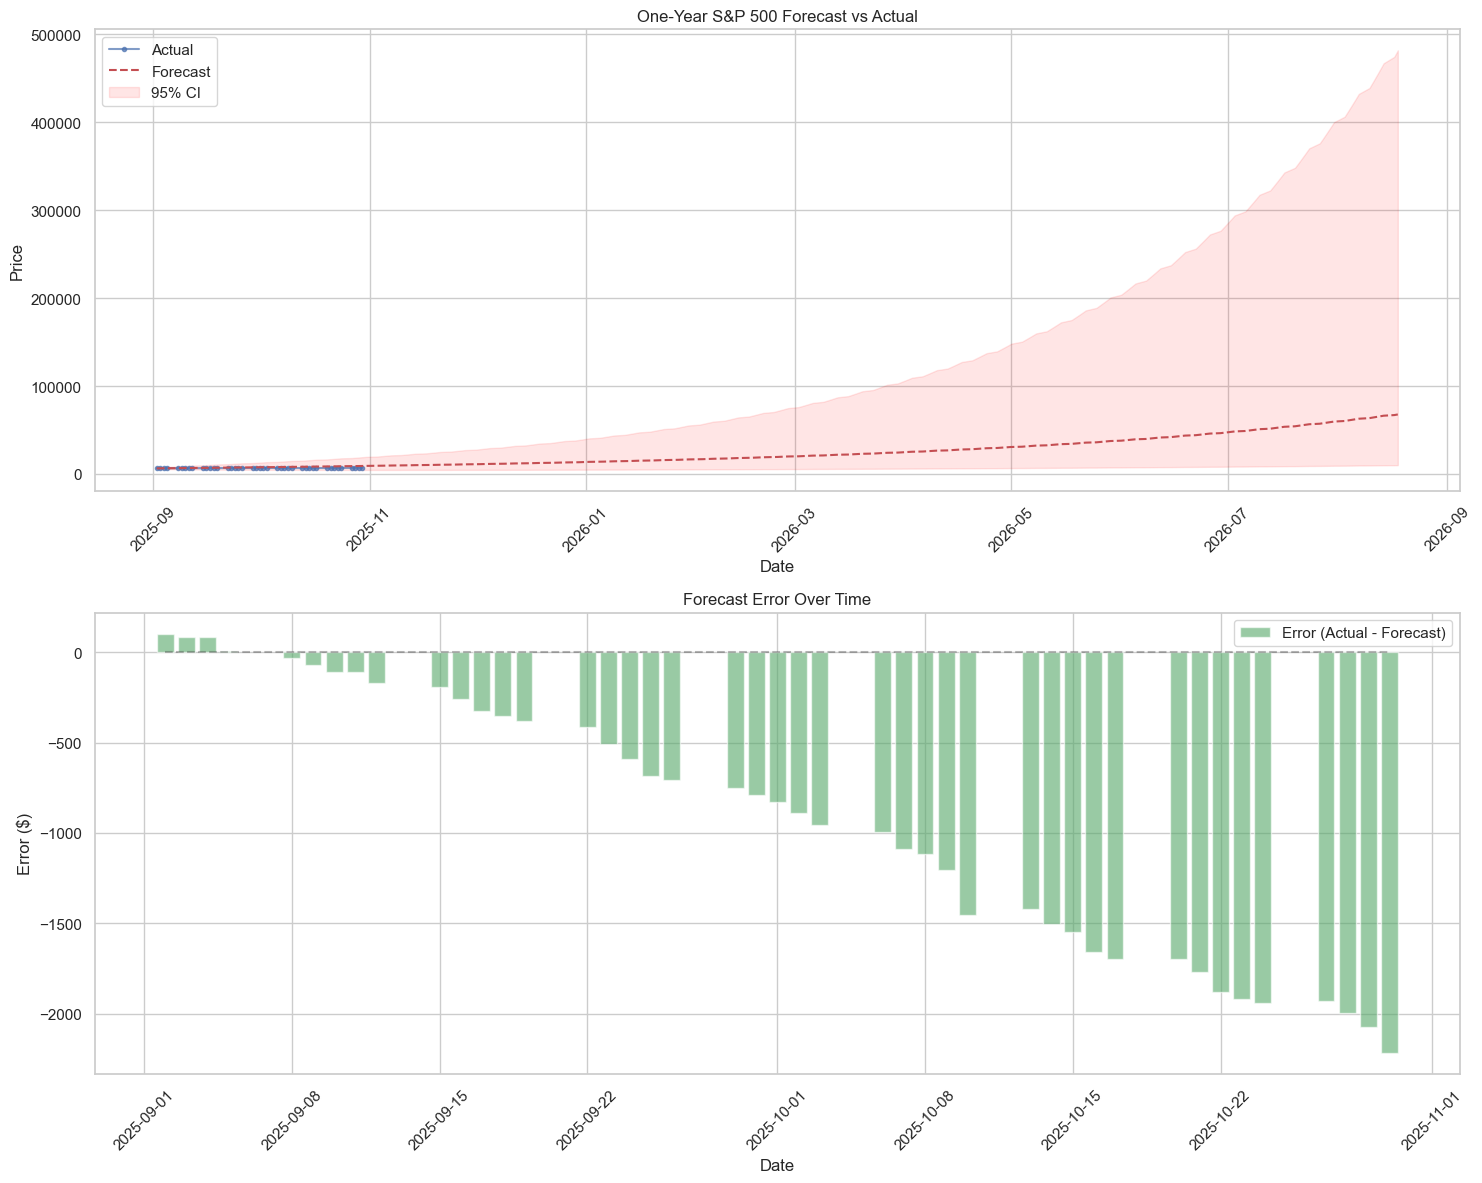

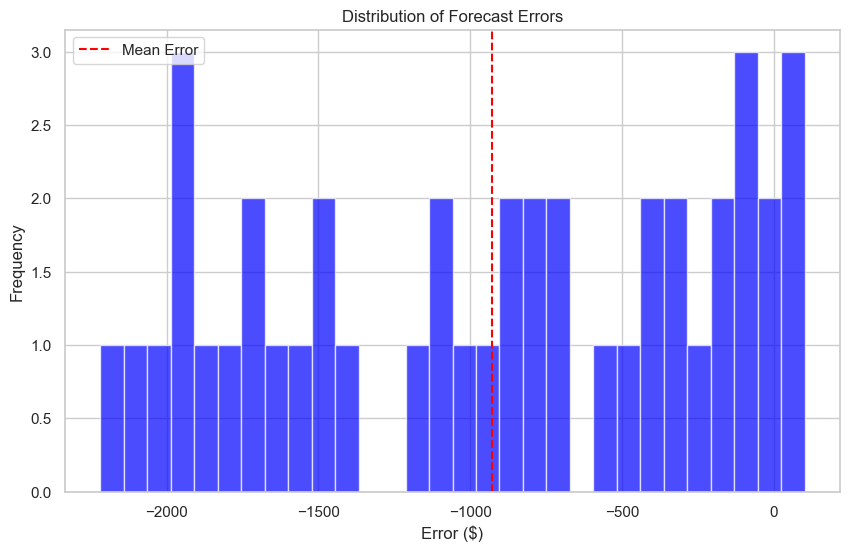

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get one-year forecast dates (252 trading days)
future_dates = pd.date_range(start=ts_m.index[-1], periods=252, freq='B')[1:]  # Business days
print("One-year forecast period:", future_dates[0], "to", future_dates[-1])

# Generate forecast
future_sarima = res.get_forecast(steps=len(future_dates))
future_sarima_mean = future_sarima.predicted_mean

# Prepare features for XGBoost for the entire year
future_features = pd.DataFrame(index=future_dates)
last_residuals = sarima_resid[-12:].values
for i in range(1, 13):
    future_features[f'lag_{i}'] = last_residuals[-i]
future_features['roll_std_6'] = sarima_resid[-6:].std()
future_features['roll_std_12'] = sarima_resid[-12:].std()
future_features['roll_mean_6'] = sarima_resid[-6:].mean()
future_features['month'] = future_dates.month

# Generate hybrid forecast
future_hybrid_log = future_sarima_mean + xgb.predict(future_features)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': np.exp(future_hybrid_log)
}).set_index('Date')

# Get actual S&P 500 data up to today
actual_df = yf.download('^GSPC', start=future_dates[0], end='2025-10-31', progress=False)[['Close']] ## Change end date as needed
actual_df.columns = ['Actual']

# Merge forecast and actual data
comparison_df = actual_df.join(forecast_df, how='outer')
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Forecast']
comparison_df['Error %'] = (comparison_df['Error'] / comparison_df['Actual']) * 100

# Print data summary
print("\nComparison of One-Year Forecast vs Actual:")
print("\nFirst few days:")
print(comparison_df.head())
print("\nLast few days:")
print(comparison_df.tail())

# Print error metrics for available actual data
valid_errors = comparison_df.dropna()
print("\nError Summary (for available actual data):")
print(f"Number of trading days compared: {len(valid_errors)}")
print(f"Mean Error: ${valid_errors['Error'].mean():.2f}")
print(f"Mean Absolute Error: ${abs(valid_errors['Error']).mean():.2f}")
print(f"Mean Percentage Error: {valid_errors['Error %'].mean():.2f}%")
print(f"Root Mean Square Error: ${np.sqrt((valid_errors['Error']**2).mean()):.2f}")

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Full forecast vs Actual
ax1.plot(comparison_df.index, comparison_df['Actual'], 'b.-', label='Actual', alpha=0.7)
ax1.plot(comparison_df.index, comparison_df['Forecast'], 'r--', label='Forecast')
ax1.fill_between(future_dates,
                 np.exp(future_sarima.conf_int().iloc[:,0]),
                 np.exp(future_sarima.conf_int().iloc[:,1]),
                 color='red', alpha=0.1, label='95% CI')
ax1.set_title('One-Year S&P 500 Forecast vs Actual')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Error Analysis (where we have actual data)
ax2.bar(valid_errors.index, valid_errors['Error'], alpha=0.6, color='g', label='Error (Actual - Forecast)')
ax2.plot(valid_errors.index, [0]*len(valid_errors.index), 'k--', alpha=0.3)
ax2.set_title('Forecast Error Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error ($)')
ax2.legend()
ax2.grid(True)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Additional visualization: Error distribution
plt.figure(figsize=(10, 6))
plt.hist(valid_errors['Error'], bins=30, alpha=0.7, color='blue')
plt.axvline(valid_errors['Error'].mean(), color='red', linestyle='--', label='Mean Error')
plt.title('Distribution of Forecast Errors')
plt.xlabel('Error ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## 6) Next Steps / What to Try
- Expand SARIMA order grid or use `auto_arima` to explore wider spaces.
- Consider modeling **daily** series with **STL + ARIMA** on seasonally adjusted component.
- Add richer features to the residual model (e.g., lagged returns of *Open/High/Low/Volume*, macro events, calendar dummies).
- Try gradient boosting alternatives (LightGBM/CatBoost) and cross-validate with time-series split.
- Evaluate out-of-time performance and stability across rolling windows.